# Lesson 7: Principal Component Analysis (PCA)

Reducing dimensions while preserving structure.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_breast_cancer, make_blobs

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. PCA Intuition: Iris Dataset

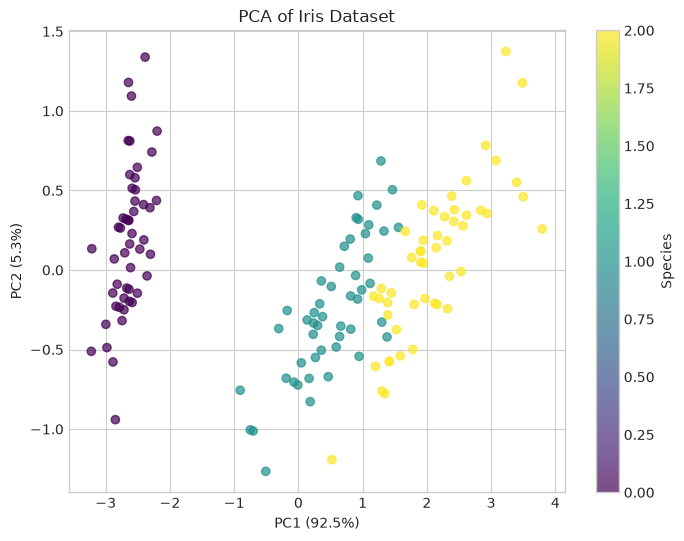

Explained variance: [0.92461872 0.05306648]
Cumulative: [0.92461872 0.97768521]


In [2]:
iris = load_iris()
X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA of Iris Dataset')
plt.colorbar(scatter, label='Species')
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative: {np.cumsum(pca.explained_variance_ratio_)}")

## 2. Explained Variance and Component Selection

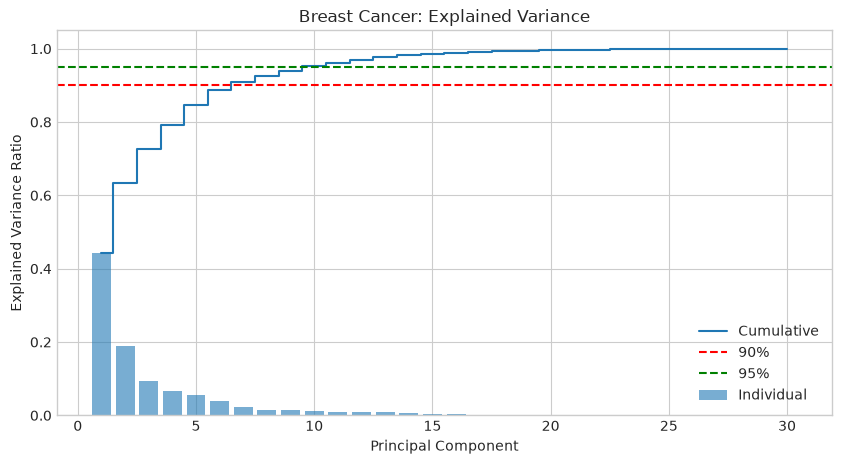

80% variance: 5 components
90% variance: 7 components
95% variance: 10 components


In [3]:
data = load_breast_cancer()
X_scaled = StandardScaler().fit_transform(data.data)

pca_full = PCA()
pca_full.fit(X_scaled)

cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 31), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.step(range(1, 31), cumulative, where='mid', label='Cumulative')
plt.axhline(y=0.9, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Breast Cancer: Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

for threshold in [0.8, 0.9, 0.95]:
    n = np.argmax(cumulative >= threshold) + 1
    print(f"{threshold:.0%} variance: {n} components")

## 3. 2D Visualization of Breast Cancer

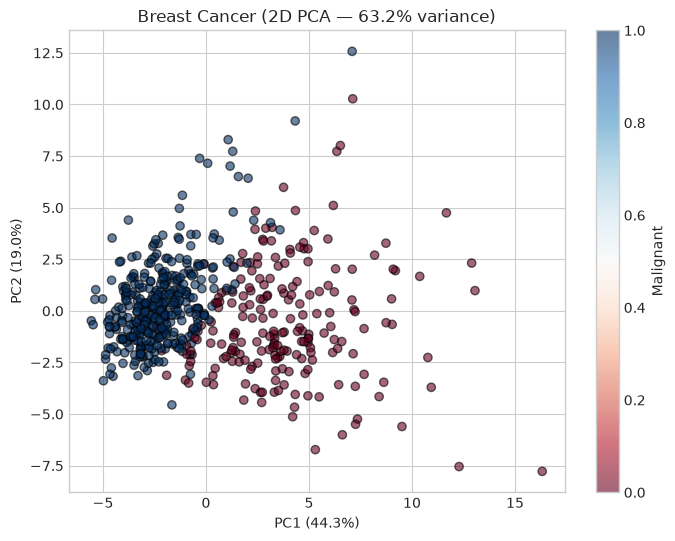

In [4]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=data.target, cmap='RdBu', alpha=0.6, edgecolors='k')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
plt.title(f'Breast Cancer (2D PCA — {pca2.explained_variance_ratio_.sum():.1%} variance)')
plt.colorbar(label='Malignant')
plt.show()

## 4. Component Loadings

In [5]:
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=['PC1', 'PC2'],
    index=data.feature_names
)

top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print("Top PC1 features:")
print(top_pc1)
print("\nTop PC2 features:")
print(top_pc2)

Top PC1 features:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64

Top PC2 features:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
Name: PC2, dtype: float64


## 5. Importance of Scaling

In [6]:
X_unscaled = np.column_stack([iris.data[:, 0] * 100, iris.data[:, 1:]])  # Sepal length × 100

pca_unscaled = PCA(n_components=2).fit(X_unscaled)
pca_scaled = PCA(n_components=2).fit(StandardScaler().fit_transform(X_unscaled))

print("Without scaling — PC1 captures:", f"{pca_unscaled.explained_variance_ratio_[0]:.1%}")
print("With scaling — PC1 captures:", f"{pca_scaled.explained_variance_ratio_[0]:.1%}")

Without scaling — PC1 captures: 100.0%
With scaling — PC1 captures: 73.0%


## 6. Biotechnology: Gene Expression

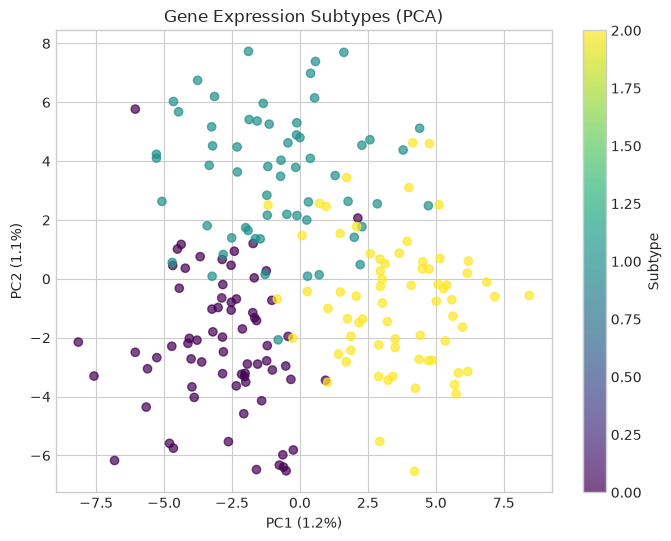

In [7]:
n_s, n_g = 200, 1000
X_expr = np.random.randn(n_s, n_g)
X_expr[:70, :50] += 0.5
X_expr[70:130, 50:100] += 0.5
X_expr[130:, 100:150] += 0.5
y_sub = np.array([0]*70 + [1]*60 + [2]*70)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_expr)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sub, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Gene Expression Subtypes (PCA)')
plt.colorbar(label='Subtype')
plt.show()

## 7. Exercises

### Level 1
If 95% variance is in 3 PCs out of 30 features, what does this imply?

### Level 2
On breast cancer, plot cumulative variance and find components for 80%, 90%, 95%.

### Level 3
PCA separates patients by age instead of disease. What went wrong?

In [8]:
# Level 2 code

## 8. Coding Challenge

Write `pca_analysis(X, n_components=2)` returning transformed data, variance ratios, and loadings.

In [9]:
def pca_analysis(X, n_components=2):
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=n_components)
    X_transformed = pca.fit_transform(X_scaled)

    pca_full = PCA().fit(X_scaled)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n_90 = np.argmax(cum >= 0.9) + 1

    print(f"Components for 90% variance: {n_90}")
    print(f"n_components={n_components}: {pca.explained_variance_ratio_.sum():.1%} variance")

    return X_transformed, pca.explained_variance_ratio_, pca.components_

Xt, var, comp = pca_analysis(iris.data, n_components=2)
print(f"Transformed shape: {Xt.shape}")
print(f"Variance ratios: {var}")

Components for 90% variance: 2
n_components=2: 95.8% variance
Transformed shape: (150, 2)
Variance ratios: [0.72962445 0.22850762]


## Summary

- PCA finds directions of maximum variance
- Eigenvectors = components; eigenvalues = variance
- Explained variance ratio guides component selection
- Always scale data before PCA
- Essential for high-dimensional visualization
- Loadings help interpret components